In [1]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library(CCA)
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
library(corrplot)
library(ggrepel)


theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [3]:
chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')

In [5]:
delta_chromatin = read.table(file = "../data/5_chromatin_delta_usage_per_gene", sep = "\t", header = T, check.names = FALSE) %>% column_to_rownames("gene_id")
lfc_isoforms = read.table(file = "../data/7_nascent_rna_isoform_log2fc_per_gene.tsv", sep = "\t", header = T) %>% column_to_rownames("gene_id")

shared_genes = unique(sort(intersect(rownames(delta_chromatin), rownames(lfc_isoforms))))

chrom_cols <- c("promoter-accessible", "intragenic-accessible",
                "co-accessible", "fully-nucleosomal", "fully-accessible")
iso_cols   <- c("lfc_tss", "lfc_citss", "lfc_atss")

df <- cbind(delta_chromatin[shared_genes, chrom_cols], lfc_isoforms[shared_genes,iso_cols])

df[is.na(df)] = 0


df_scaled <- df %>% mutate(across(all_of(c(chrom_cols, iso_cols)), scale))

chrom_sel <- df_scaled %>% dplyr::select(all_of(chrom_cols))
iso_sel   <- df_scaled %>% dplyr::select(all_of(iso_cols))

cor_mat <- matrix(NA, length(chrom_cols), length(iso_cols),
                  dimnames = list(chrom_cols, iso_cols))
p_mat <- cor_mat

for (r in seq_along(chrom_cols)) {
  for (c in seq_along(iso_cols)) {
    ct <- suppressWarnings(
      cor.test(chrom_sel[[r]], iso_sel[[c]],
               method = "spearman", use = "pairwise.complete.obs")
    )
    cor_mat[r, c] <- ct$estimate
    p_mat[r, c]   <- ct$p.value
  }
}

p_adj <- matrix(p.adjust(p_mat, method = "BH"),
                nrow = nrow(p_mat), dimnames = dimnames(p_mat))

sig_stars <- function(p) {
  ifelse(p < 0.001, "***",
  ifelse(p < 0.01,  "**",
  ifelse(p < 0.05,  "*", "")))
}

pdf 
  2

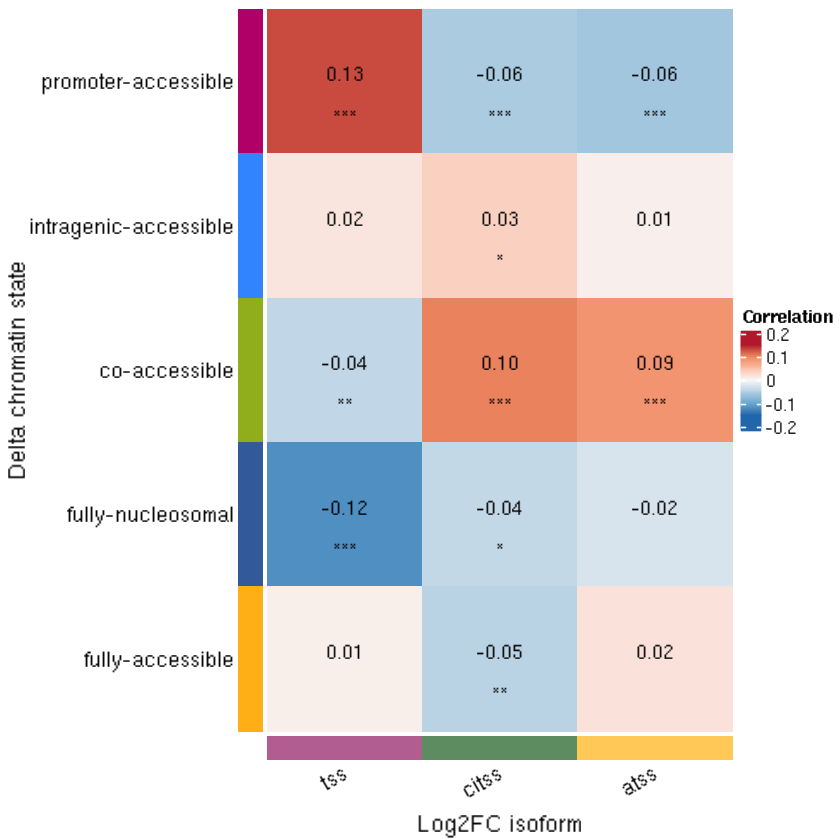

In [8]:
cell_fun = function(j, i, x, y, w, h, fill) {
  grid.text(sprintf("%.2f", cor_mat[i, j]),
            x, y + unit(0.01, "npc"), gp = gpar(fontsize = 11))
  grid.text(sig_stars(p_adj[i, j]),
            x, y + unit(-0.05, "npc"),
            gp = gpar(fontsize = 11))
}


chrom_col <- polychrome()[c(7, 10, 8, 6, 15)]
names(chrom_col) <- c("fully-accessible", "co-accessible", "promoter-accessible",
                     "intragenic-accessible", "fully-nucleosomal")
chrom_col = chrom_col[chrom_level]

cor_mat <- cor_mat[chrom_level, ]
p_adj   <- p_adj[chrom_level, ]

iso_level = c("tss", "citss", "atss")
colnames(cor_mat)<- iso_level
iso_col <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
names(iso_col) <- iso_level

row_ha <- rowAnnotation(
  State = chrom_level,
  col   = list(State = chrom_col),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

col_ha <- HeatmapAnnotation(
  State = iso_level,
  col   = list(State = iso_col),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

ht <- Heatmap(cor_mat,
        name = "Correlation",
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        col = colorRamp2(c(-0.15, -0.1, 0, 0.1, 0.15), c("#2166ac", "#67a9cf", "#f7f7f7", "#ef8a62", "#b2182b")),
        row_title = "Delta chromatin state",
        column_title = "Log2FC isoform",
        column_title_side = "bottom",
        column_names_rot = 30,
        show_row_dend = FALSE,
        show_column_dend = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        column_names_side = "bottom",
        row_names_side = "left",
        left_annotation = row_ha,
        top_annotation = NULL,
        bottom_annotation = col_ha,
        cell_fun = cell_fun)

draw(ht)

pdf('../figures/Supp_spearman_correlation_delta_chromain_and_Log2FC_nascent isoform.pdf', width = 5, height = 4)
draw(ht,      
     column_title = "Spearman correlation\nDelta chromatin states vs Log2FC nascent isoform",
     column_title_gp = gpar(fontsize = 12),
     heatmap_legend_side = "right")
dev.off()

draw(ht, heatmap_legend_side = "right")